## **Random Imputation**
* Used most commonly.
* Replace using random numbers(selected randomly from other numbers present in our column)
* can be applied on both numerical as well as categorical
* sklearn doesn't support, use pandas.
* does not affect variation/ distribution of data(minimal changes).
* good for linear algo, not for non linear.
* Con : Memeory heavy for deployment, have to use training dataat server so random values can be chosen from them.

**Code:**

### For Numerical data

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [6]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_train['Age']

In [12]:
# Impute missing values in X_train
X_train.loc[X_train['Age'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(), random_state=2).values
)

# Impute missing values in X_test using values from X_test
X_test.loc[X_test['Age'].isnull(), 'Age_imputed'] = (
    X_test['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=2).values
)

# If you want to use X_train values for X_test imputation, use this instead:
# X_test.loc[X_test['Age'].isnull(), 'Age_imputed'] = (
#     X_train['Age'].dropna().sample(X_test['Age'].isnull().sum(), random_state=2).values
# )


In [13]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,22.0
493,71.0,49.5042,71.0
527,NaN,221.7792,24.0


<ipython-input-15-2b34de8330f2>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original')
<ipython-input-15-2b34de8330f2>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label='Imputed')


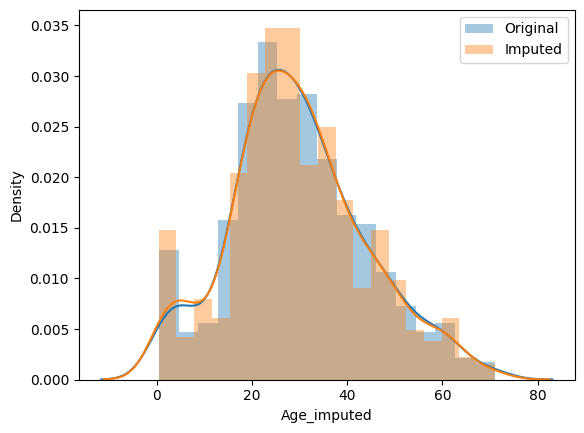

In [15]:
sns.distplot(X_train['Age'],label='Original')
sns.distplot(X_train['Age_imputed'],label='Imputed')

plt.legend()
plt.show()

In [16]:
#check variance
print('Age',X_train['Age'].var())
print('Imputed age',X_train['Age_imputed'].var())

Age 204.3495133904614
Imputed age 204.89693517517654


* Minimal to no changes in variance

In [19]:
X_train.head(2)

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0


In [18]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,60.625724
Age,71.512440,204.349513,204.349513
Age_imputed,60.625724,204.349513,204.896935


* However drastic changes in co varaince

In [ ]:
#In production environment
#Note : remember for same age input fare alwayr remain smae like for 19 if fare is x thn for other person with age 19 th fare should also be x
sampled_value = X_train['Age'].dropna().sample(1, random_state = int(observation['Fare']))

### For Categorical data

In [20]:
'''
Import data
create x and y
train test split
create col as imputed_col for both train and test, and use above same technique

'''

#Refer to yt for code

'\nImport data\ncreate x and y\ntrain test split\ncreate col as imputed_col for both train and test, and use above same technique \n\n'

# **Missing Indicator**

* In it we create a new column that serves as flag in the row if value is not missing, it is False otherwise it is True.
* This helps our model to differentiate b/w missing rows and non- missing rows.
* So we can try on our model, if it helps improve efficiency use it, else discard it.

In [ ]:
'''
read data
create x and y
train test split
create object of missingIndicator() class of sk-learn
then fit on train
check obj,features_y.
create var : X_train_missing = obj.transform(X_train)
chack X_train_missing -> returns array
X_train = ['Miss_ind ] = X_train_missing
X_test = ['Miss_ind ] = X_tes_missing
X_train

si = SimpleImputer()
si.fit(X_train)
X_train = si.transform(X_train)
X_test = si.transform(X_test)
X_train

si= SimpleImputer(add_indicator=True)
si.fit(X_train)
X_train = si.transform(X_train)
X_test = si.transform(X_test)
X_train

and check accuarcy:
clf = LogisticRegression()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

'''

#Simple Imputer also supports missing imputer class as well,
'''
si = SimpleImputer(add_indicator=True) # self - ind supports MI
si.fit(X_train)
X_train = si.transform(X_train)
X_test = si.transform(X_test)
X_train
'''

# **Automatically select vlaue for imputation**

* grid searchCv
* sklearn tries all combinations, and returns the best one.

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression


In [22]:
df = pd.read_csv('train.csv')

In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [26]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


->  Missing value in age and embarked.

In [27]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Drop unnecessary columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Define target and features
y = df['Survived']
X = df.drop(columns=['Survived'])

# Identify numerical and categorical columns
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Define preprocessing steps
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Define full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Define hyperparameter grid
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1, 10]
}

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Evaluate on test set
print("Test Accuracy:", grid_search.best_estimator_.score(X_test, y_test))


Best Parameters: {'classifier__C': 0.1, 'preprocessor__cat__imputer__strategy': 'constant', 'preprocessor__num__imputer__strategy': 'median'}
Best Score: 0.7948980596867921
Test Accuracy: 0.7988826815642458


In [30]:
#refer to yt. documentation for detailed code